### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [33]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [34]:
from langchain_groq import ChatGroq
model = ChatGroq(model="qwen/qwen3-32b")
model

ChatGroq(output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7eb99cca27a0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7eb99cca2e00>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

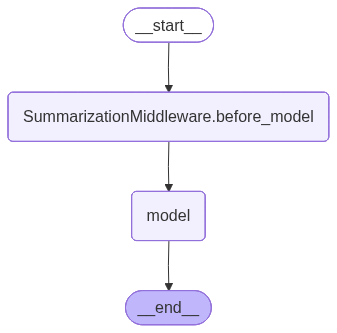

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Messagebased summarization
agent=create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [23]:
# Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [24]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
    "what is 100 * 0",
    "what is 0 * 100"
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='c672399a-c6be-4a5c-8023-342ca71672c1'), AIMessage(content='<think>\nOkay, so the user is asking "What is 2+2?" Hmm, that seems straightforward. Let me make sure I\'m not missing anything here. Basic arithmetic, right? Addition of two numbers. Let\'s start by recalling the fundamental principles of addition. When you add two numbers together, you\'re combining their quantities. So 2 plus 2 means you have a quantity of 2 and another quantity of 2, and you combine them.\n\nWait, maybe I should visualize this. If I have two apples and someone gives me two more apples, how many do I have in total? That would be four apples. So the answer should be 4. But let me check another way. Using fingers: hold up two fingers on one hand, two on the other, count them all—1, 2, 3, 4. Yep, that\'s four. \n\nIs there any alternative interpretation where 2+2 might not be 4? Like in modular arithmeti

In [26]:
len(str(response))

14251

## token Size

In [27]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


agent=create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("tokens",550),
            keep=("tokens",200),
        ),
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

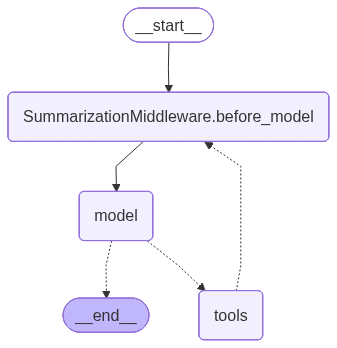

In [28]:
agent

In [29]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~147 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='3ff1655a-f8a6-470a-a4db-50bff3d85ec7'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking to find hotels in Paris. Let me check the available tools. There\'s a function called search_hotels that takes a city parameter. The description says it returns a long response to use more tokens. Since the user wants hotels in Paris, I need to call this function with the city set to Paris. I should make sure the arguments are correctly formatted as JSON. Alright, I\'ll structure the tool call with the name search_hotels and the arguments as {"city": "Paris"}. Let me double-check if the city is required, and yes, it\'s in the required array. Everything looks good. Time to output the tool call in the specified XML tags.\n', 'tool_calls': [{'id': 'w1dhr1jbk', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': '

### Fraction

In [37]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model=model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~67 tokens (0.0523%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='dd1c7026-f52b-4206-874c-ab350425d96f'), AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for hotels in Paris. Let me check the available tools. There's a function called search_hotels that requires a city parameter. The user mentioned Paris, so I need to call that function with the city set to Paris. I should make sure the JSON is correctly formatted with the city name in quotes. Let me structure the tool_call accordingly.\n", 'tool_calls': [{'id': 's8rqyd611', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 147, 'total_tokens': 247, 'completion_time': 0.150613745, 'completion_tokens_details': {'reasoning_tokens': 75}, 'prompt_time': 0.006872792, 'prompt_tokens_details': None, 'queue_time': 0.046328514

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware, SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [40]:
agent=create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        ), SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

In [41]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [42]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='d2d96fa8-1e9e-4167-a7ec-078d9511086d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you?. So I need to call the send_email_tool with those arguments. No issues here since all required parameters are present. I'll format the tool_call accordingly.\n", 'tool_calls': [{'id': '25pgg9txq', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, res

In [43]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email with the subject "Hello" has been successfully sent to john@test.com. The body of the email reads: "How are you?". Let me know if you need further assistance!


In [44]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='d2d96fa8-1e9e-4167-a7ec-078d9511086d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you?. So I need to call the send_email_tool with those arguments. No issues here since all required parameters are present. I'll format the tool_call accordingly.\n", 'tool_calls': [{'id': '25pgg9txq', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, res

### Reject

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=model,
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
        SummarizationMiddleware(
            model=model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ],
)

In [45]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [46]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email to john@test.com with subject "Hello" was not sent. Would you like me to try sending it again?


In [47]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='5adcb8d4-5c03-455b-b243-805670486c16'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user wants to send an email to john@test.com with the subject 'Hello' and body 'How are you?'. Let me check the available tools. There's the send_email_tool which requires recipient, subject, and body. All three are required. The parameters are all strings. The user provided all three pieces of information: recipient is john@test.com, subject is Hello, body is How are you?. So I need to call send_email_tool with those arguments. No issues here. Just structure the JSON with those parameters. Make sure the JSON is correctly formatted. No need to use the read_email_tool since the user isn't asking to read an email. Alright, ready to output the tool call.\n", 'tool_calls': [{'id': 'gb30vzn7h', 'function': {'arguments': '

### Editing

In [48]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="gpt-4o",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [50]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [ ]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='078c852f-cc67-4e0e-bee2-1e80e8d52598'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 95, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff5f7093b3', 'id': 'chatcmpl-Co4I843MzNcaHARohEYFcE1RGYiJy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--16d13698-ce64-4c47-aa2d-d1074c4b9032-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'wrong@email.com', 'subject': 'Test', 'body': 'Hello'}, 'id': 'call_8bku3hoUOJqnnR2FUM2ZO61d', '

In [26]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been successfully sent.


In [27]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='078c852f-cc67-4e0e-bee2-1e80e8d52598'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 95, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ff5f7093b3', 'id': 'chatcmpl-Co4I843MzNcaHARohEYFcE1RGYiJy', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--16d13698-ce64-4c47-aa2d-d1074c4b9032-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipient': 'correct@email.com', 'subject': 'Corrected Subject', 'body': 'This was edit